Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Cloning https://www.github.com/mouseland/cellpose.git to /tmp/pip-req-build-j8t31xfj
  Running command git clone --filter=blob:none --quiet https://www.github.com/mouseland/cellpose.git /tmp/pip-req-build-j8t31xfj
  Resolved https://www.github.com/mouseland/cellpose.git to commit 17fb25f40055ec2636aa708dc4cf6625b8b4735d
  Preparing metadata (setup.py) ... done
2025-12-03 17:45:38,001 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2025-12-03 17:45:38,002 [INFO] 
cellpose version: 	4.0.8.dev29+g17fb25f40 
platform:       	linux 
python version: 	3.12.12 
torch version:  	2.9.0+cu126
2025-12-03 17:45:38,004 [INFO] ** TORCH CUDA version installed and working. **
2025-12-03 17:45:38,005 [INFO] ** TORCH CUDA version installed and working. **
2025-12-03 17:45:38,007 [INFO] >>>> using GPU (CUDA)
2025-12-03 17:45:40,487 [INFO] >>>> loading model /root/.cellpos

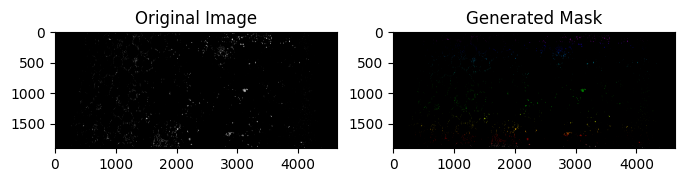

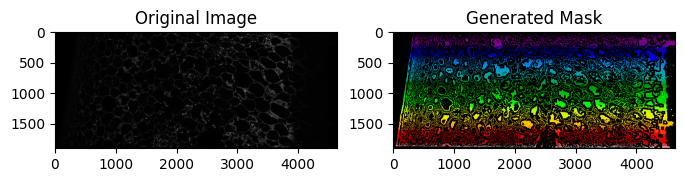

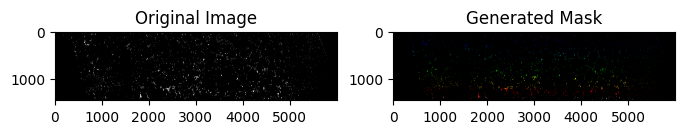

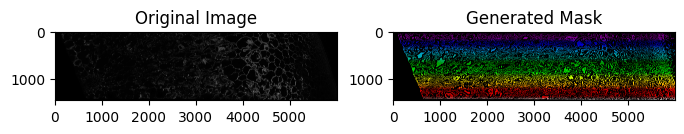

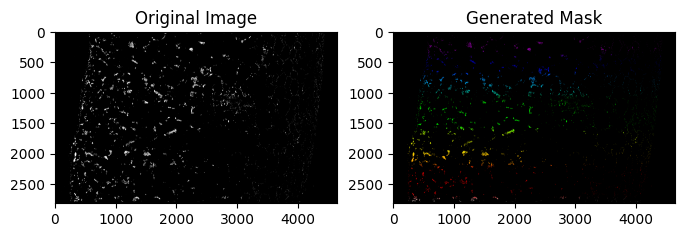

...

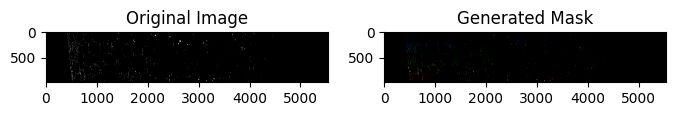

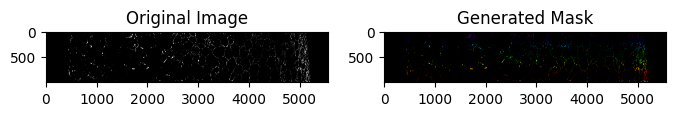

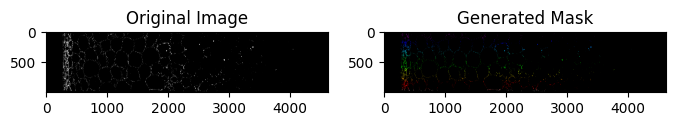

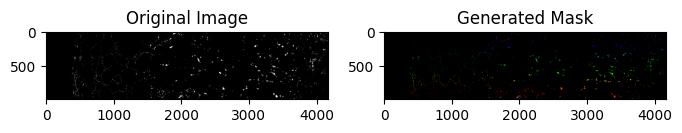

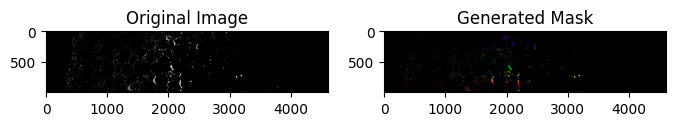

✅ Instance masks generated and saved as _masks.png


In [ ]:
# --------------------------
# 1️⃣ Mount Google Drive
# --------------------------
from google.colab import drive
drive.mount('/content/drive')

# --------------------------
# 2️⃣ Install Cellpose
# --------------------------
!pip install git+https://www.github.com/mouseland/cellpose.git

# --------------------------
# 3️⃣ Imports
# --------------------------
import numpy as np
from cellpose import models, core, io, plot
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from PIL import Image  # Added this import
from skimage import filters, morphology, measure
from scipy import ndimage as ndi
from skimage import feature, segmentation

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

model = models.CellposeModel(gpu=True)

# --------------------------
# 4️⃣ Folders
# --------------------------
input_dir = Path("/content/drive/")  # folder with raw images
output_masks =output_folder_masks  = Path("/content/drive/")
output_masks.mkdir(exist_ok=True, parents=True)

# --------------------------
# 5️⃣ Generate instance masks
# --------------------------
image_files = sorted([f for f in input_dir.glob("*.jpg") if "_masks" not in f.name])

for img_path in image_files:
    name = img_path.stem
    img = np.array(Image.open(img_path).convert("L"))

    # Adaptive/local threshold (works better for confocal images)
    block_size = 35  # can tune depending on cell size
    local_thresh = filters.threshold_local(img, block_size)
    binmask = (img > local_thresh).astype(np.uint8)

    # Clean small objects / holes
    binmask = morphology.remove_small_objects(binmask.astype(bool), min_size=5).astype(np.uint8)
    binmask = morphology.remove_small_holes(binmask.astype(bool), area_threshold=20).astype(np.uint8)

    # Distance transform and markers
    distance = ndi.distance_transform_edt(binmask)
    coordinates = feature.peak_local_max(distance, footprint=np.ones((3,3)), labels=binmask)
    local_maxi = np.zeros(distance.shape, dtype=bool)
    if len(coordinates) > 0:
        local_maxi[tuple(coordinates.T)] = True
    markers = ndi.label(local_maxi)[0]

    # Watershed → instance mask
    labels = segmentation.watershed(-distance, markers, mask=binmask)
    labels = morphology.remove_small_objects(labels, min_size=5)
    labels = measure.label(labels)

    # Save instance mask as _masks.png for Cellpose
    mask_save_path = output_masks / f"{name}_masks.png"
    Image.fromarray(labels.astype(np.uint16)).save(mask_save_path)

    # Optional: visualize
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Image')
    plt.subplot(1,2,2)
    plt.imshow(labels, cmap='nipy_spectral')
    plt.title('Generated Mask')
    plt.show()

print("✅ Instance masks generated and saved as _masks.png")

In [ ]:
from pathlib import Path

train_dir = Path("/content/drive/MyDrive/")

images = sorted([f.name for f in train_dir.glob("*.jpg") if "_masks" not in f.name])
masks = sorted([f.name for f in train_dir.glob("*_masks.jpg")])

print("Images:", len(images))
print("Masks:", len(masks))

# show first 40 pairs
print("\n--- First 40 images ---")
for img in images[:40]:
    print(img)

print("\n--- First 40 masks ---")
for m in masks[:40]:
    print(m)


Images: 0
Masks: 0

--- First 40 images ---

--- First 40 masks ---


In [ ]:
from pathlib import Path

folder = Path("/content/drive/MyDrive//")
images = [p for p in folder.glob("*.jpeg") if "_masks" not in p.name]
masks  = [p for p in folder.glob("*.jpeg") if "_masks" in p.name]

# Build dict of masks by base name
mask_dict = {}
for m in masks:
    base = m.name.replace("_masks.jpeg", "")
    mask_dict[base] = m

for img in images:
    base = img.stem
    correct_mask_name = f"{base}_masks.jpeg"
    correct_mask_path = folder / correct_mask_name

    # Mask exists under a wrong name → fix it
    if base in mask_dict:
        m = mask_dict[base]
        if m.name != correct_mask_name:
            print(f"Renaming {m.name} → {correct_mask_name}")
            m.rename(correct_mask_path)

print("✅ All mask names fixed.")

✅ All mask names fixed.


In [ ]:
# *** change to your google drive folder path ***
train_dir = "/content/drive/MyDrive/traindatapng_resized"
if not Path(train_dir).exists():
  raise FileNotFoundError("directory does not exist")

test_dir = None # optionally you can specify a directory with test files

# *** change to your mask extension ***
masks_ext = "_masks.jpeg"
# ^ assumes images from Cellpose GUI, if labels are tiffs, then "_masks.tif"

# list all files
files = [f for f in Path(train_dir).glob("*") if "_masks" not in f.name and "_flows" not in f.name and "_seg" not in f.name]

if(len(files)==0):
  raise FileNotFoundError("no files found, did you specify the correct folder and extension?")
else:
  print(f"{len(files)} files in folder:")

for f in files:
  print(f.name)

40 files in folder:
ech12292-30dpa-TerradouTemoin.png
ech12302-30dpa-H1311Temoin.png
ech12308-30dpa-TerradouWD.png
ech12314-30dpa-TerradouWD.png
ech12315-12dpa-H1311Temoin.png
ech12317-12dpa-TerradouTemoin.png
ech12317-30dpa-H1311WD.png
ech12319-12dpa-H1311Temoin.png
ech12320-12dpa-H1311Temoin.png
ech12321-12dpa-TerradouWD.png
ech12322-12dpa-TerradouWD.png
ech12322-30dpa-H1311Temoin.png
ech12325-12dpa-H1311WD.png
ech12326-12dpa-H1311WD.png
ech12347-30dpa-H1311Temoin.png
ech12348-30dpa-TerradouTemoin.png
ech12349-20dpa-TerradouTemoin.png
ech12351-20dpa-TerradouTemoin.png
ech12361-20dpa-H1311Temoin.png
ech12363-20dpa-H1311Temoin.png
ech12371-20dpa-TerradouWD.png
ech12375-20dpa-TerradouWD.png
ech12381-20dpa-H1311WD.png
ech12387-20dpa-H1311WD.png
ech12409-40dpa-TerradouTemoinT.png
ech12409b-40dpa-TerradouTemoinT.png
ech12419-40dpa-TerradouWDT.png
ech12419b-40dpa-TerradouWDT.png
ech12429-40dpa-H1311TemoinT.png
ech12429b-40dpa-H1311TemoinT.png
ech12439-40dpa-H1311WDT.png
ech12439b-40dpa-H131

In [ ]:
from cellpose import train, io
from pathlib import Path
import numpy as np

model_name = "new_model"

# default training params
n_epochs = 100
learning_rate = 1e-5
weight_decay = 0.1
batch_size = 1

# *** Manual loading and renaming to ensure all masks are found and paired ***
# This will replace the io.load_train_test_data call entirely.

train_data = []
train_labels = []

# Step 1: Get all image and mask file paths
raw_image_files = sorted([f for f in Path(train_dir).glob("*.png") if "_masks" not in f.name and "_flows" not in f.name and "_seg" not in f.name])
# Collect all mask files and map them by their *current* filename for easier lookup during renaming
all_current_mask_files = {m.name: m for m in Path(train_dir).glob("*_masks.png")}

renamed_count = 0
images_without_masks = []
successfully_paired_images = []

print("--- Starting mask file validation and renaming ---")

for img_path in raw_image_files:
    base_img_stem = img_path.stem
    correct_mask_name = f"{base_img_stem}{masks_ext}"
    correct_mask_path = img_path.parent / correct_mask_name
 # Assume no mask found yet for this image
    found_mask_for_image = False

    # Check if the correct mask name already exists
    if correct_mask_path.exists():
        found_mask_for_image = True
        successfully_paired_images.append((img_path, correct_mask_path))
        continue # Move to the next image

    # Try to find and rename an incorrect mask
    potential_incorrect_mask_names = []

    # 1. Echa prefix variation (e.g., echa123..._masks.png for ech123...)
    if base_img_stem.startswith("ech"):
        potential_incorrect_mask_names.append(f"echa{base_img_stem[3:]}{masks_ext}")

    # 2. Hyphen-to-underscore variation (e.g., ech123_12dpa_..._masks.png for ech123-12dpa-...)
    if '-' in base_img_stem:
        potential_incorrect_mask_names.append(f"{base_img_stem.replace('-', '_')}{masks_ext}")

    # 3. Echa prefix AND hyphen-to-underscore variation
    if base_img_stem.startswith("ech") and '-' in base_img_stem:
        potential_incorrect_mask_names.append(f"echa{base_img_stem[3:].replace('-', '_')}{masks_ext}")

    # Check if any of these potential incorrect masks exist in our collected mask files
    for potential_mask_name in potential_incorrect_mask_names:
        if potential_mask_name in all_current_mask_files:
            existing_incorrect_mask_path = all_current_mask_files[potential_mask_name]
            print(f"Renaming mask: {existing_incorrect_mask_path.name} -> {correct_mask_name}")
            existing_incorrect_mask_path.rename(correct_mask_path)
            renamed_count += 1
            found_mask_for_image = True
            successfully_paired_images.append((img_path, correct_mask_path))

            # Update all_current_mask_files to reflect the rename (important for subsequent images)
            del all_current_mask_files[potential_mask_name]
            all_current_mask_files[correct_mask_name] = correct_mask_path
            break # Found and renamed, move to next image

    if not found_mask_for_image:
        images_without_masks.append(img_path.name)

if renamed_count > 0:
    print(f"Fixed {renamed_count} mask name(s).")
else:
    print("No mask names required fixing.")

if images_without_masks:
    print("\n--- Images without matching masks ---")
    for img_name in images_without_masks:
        print(f"Warning: No matching mask found for image: {img_name}")
    raise ValueError("Cannot proceed with training: some images do not have corresponding masks after attempted renaming.")
else:
    print("All image files have a corresponding mask file.")

print("\n--- Loading image and mask data ---")
# Now that all masks are correctly named, load them
for img_path, mask_path in successfully_paired_images:
    try:
        img = io.imread(str(img_path))
        mask = io.imread(str(mask_path))
        train_data.append(img)
        train_labels.append(mask)
    except Exception as e:
        raise RuntimeError(f"Failed to load image {img_path.name} or mask {mask_path.name}: {e}")

print(f"Successfully loaded {len(train_data)} image-mask pairs for training.")

# Set test_data and test_labels to None as we are not using them for this example
test_data = None
test_labels = None

# Proceed with training as before, but without io.load_train_test_data
new_model_path, train_losses, test_losses = train.train_seg(model.net,
                                                            train_data=train_data,
                                                            train_labels=train_labels,
                                                            batch_size=batch_size,
                                                            n_epochs=n_epochs,
                                                            learning_rate=learning_rate,
                                                            weight_decay=weight_decay,
                                                            nimg_per_epoch=max(2, len(train_data)), # can change this
                                                            model_name=model_name)

--- Starting mask file validation and renaming ---
No mask names required fixing.
All image files have a corresponding mask file.

--- Loading image and mask data ---
Successfully loaded 40 image-mask pairs for training.
2025-12-01 02:13:17,775 [INFO] computing flows for labels


100%|██████████| 40/40 [00:01<00:00, 34.06it/s]

2025-12-01 02:13:18,960 [INFO] >>> computing diameters



100%|██████████| 40/40 [00:00<00:00, 3145.16it/s]

2025-12-01 02:13:18,976 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2025-12-01 02:13:19,031 [INFO] >>> n_epochs=100, n_train=40, n_test=None
2025-12-01 02:13:19,031 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.10000
2025-12-01 02:13:19,035 [INFO] >>> saving model to /content/models/new_model
2025-12-01 02:13:56,557 [INFO] 0, train_loss=0.8599, test_loss=0.0000, LR=0.000000, time 37.52s
2025-12-01 02:17:12,918 [INFO] 5, train_loss=0.7923, test_loss=0.0000, LR=0.000006, time 233.88s
2025-12-01 02:20:31,606 [INFO] 10, train_loss=0.6239, test_loss=0.0000, LR=0.000010, time 432.57s
2025-12-01 02:27:08,766 [INFO] 20, train_loss=0.4965, test_loss=0.0000, LR=0.000010, time 829.73s
2025-12-01 02:33:45,461 [INFO] 30, train_loss=0.4657, test_loss=0.0000, LR=0.000010, time 1226.43s
2025-12-01 02:40:22,467 [INFO] 40, train_loss=0.4374, test_loss=0.0000, LR=0.000010, time 1623.43s
2025-12-01 02:46:59,310 [INFO] 50, train_loss=0.4431, test_loss=0.0000, LR=0.000005, time 2020.28s
2025-12-01 02:53:35,855 [INFO] 60, train_loss=0.4284, test_loss=0.0000, LR=0.0

In [ ]:
print(len(train_data), "images used for training")
print(len(train_labels), "masks used for training")

40 images used for training
40 masks used for training


TESTING THE MODEL PART


In [ ]:
!pip install git+https://www.github.com/mouseland/cellpose.git

import numpy as np
from cellpose import models, core, io, plot, utils, transforms
from pathlib import Path
import matplotlib.pyplot as plt

io.logger_setup()

if core.use_gpu()==False:
    raise ImportError("No GPU access, change your runtime")

model_path = "/content/models/new_model"   # path to your trained model
model = models.CellposeModel(gpu=True, pretrained_model=model_path)


  Cloning https://www.github.com/mouseland/cellpose.git to /tmp/pip-req-build-btwyhttb
  Running command git clone --filter=blob:none --quiet https://www.github.com/mouseland/cellpose.git /tmp/pip-req-build-btwyhttb
  Resolved https://www.github.com/mouseland/cellpose.git to commit 9604421222c51d96636c2547e33fbd7d4f766c2a
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 117.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 94.3 MB/s eta 0:00:00
  Created wheel for cellpose: filename=cellpose-4.0.8.dev24+g960442122-py3-none-any.whl size=212893 sha256=df76185c379cbcfe0cc7961d364a669feb6e49d88128ca09da05d1f6032b5437
  Stored in directory: /tmp/pip-ephem-wheel-cache-og1zty2f/wheels/df/b6/31/a3013c44290eabb46f4c06d1efb19744124fcad2d59684ec5e
Successfully built cellpose
creating new log file
2025-12-01 04:42:10,278 [INFO] WRITING LOG OUTPUT TO 

100%|██████████| 1.15G/1.15G [00:06<00:00, 204MB/s]


2025-12-01 04:55:36,068 [INFO] ** TORCH CUDA version installed and working. **
2025-12-01 04:55:36,069 [INFO] >>>> using GPU (CUDA)
2025-12-01 04:55:36,070 [WARNING] pretrained model /root/.cellpose/models/cpsam not found, using default model
2025-12-01 04:55:39,435 [INFO] >>>> loading model /root/.cellpose/models/cpsam
2025-12-01 04:55:41,840 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


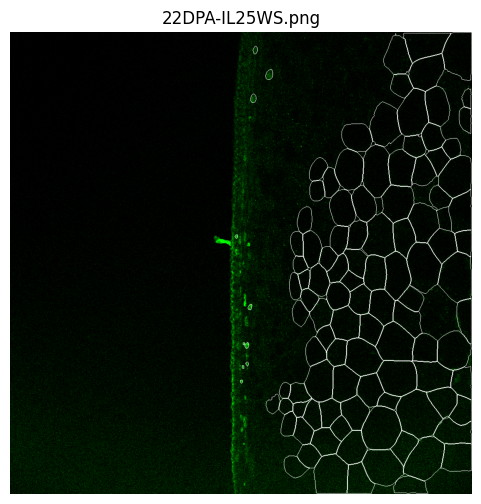

2025-12-01 04:55:53,358 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


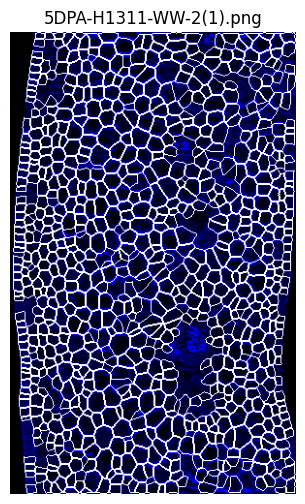

2025-12-01 04:55:56,862 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


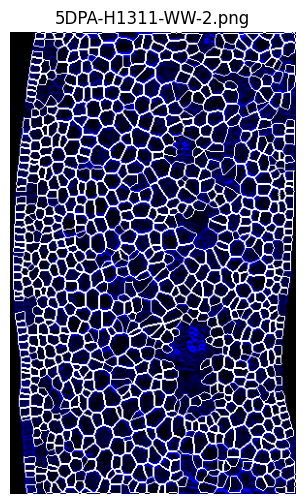

2025-12-01 04:56:02,027 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


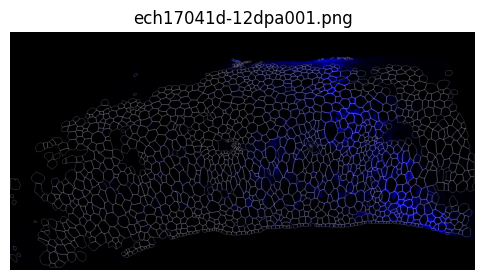

2025-12-01 04:57:10,427 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


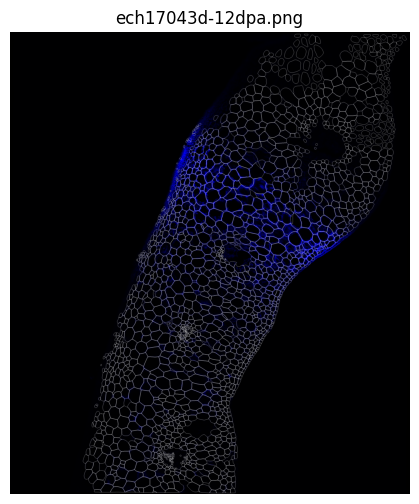

2025-12-01 04:58:38,695 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


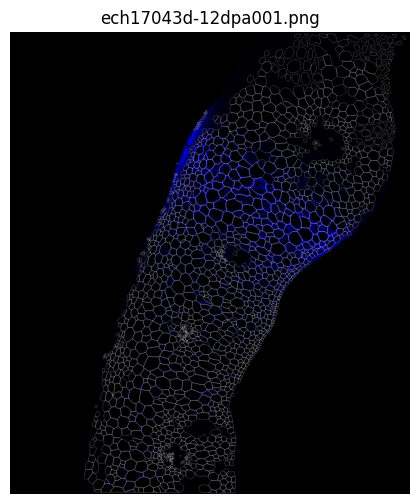

2025-12-01 05:00:06,533 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


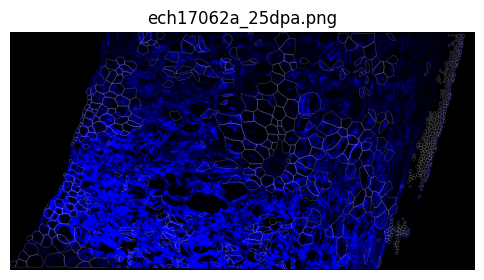

2025-12-01 05:01:18,020 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


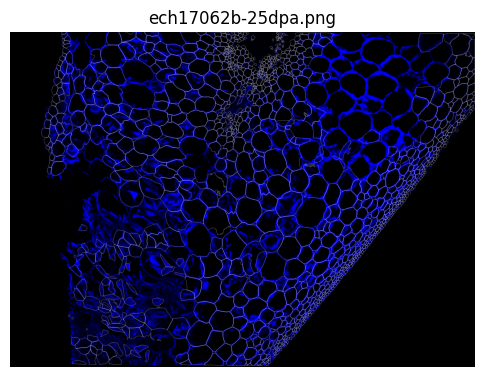

2025-12-01 05:02:40,557 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


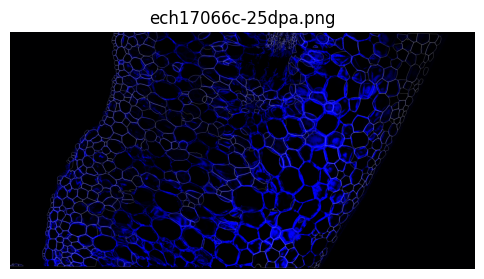

2025-12-01 05:04:28,592 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


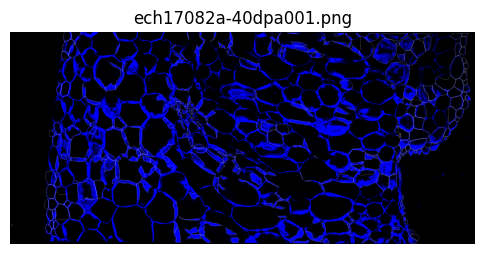

2025-12-01 05:05:37,784 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


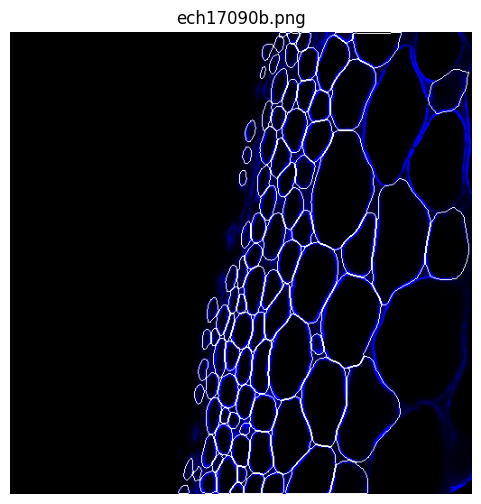

2025-12-01 05:05:43,144 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


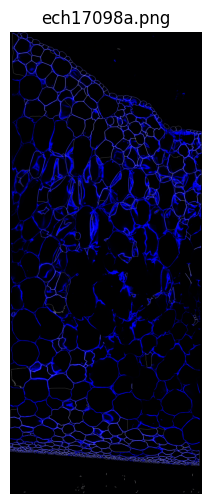

2025-12-01 05:07:13,636 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


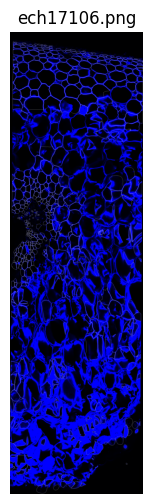

2025-12-01 05:08:26,593 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


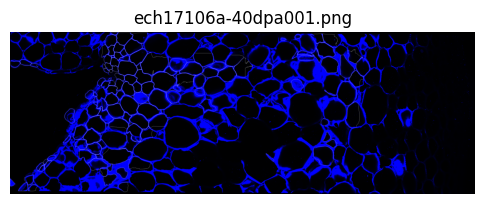

2025-12-01 05:09:23,692 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


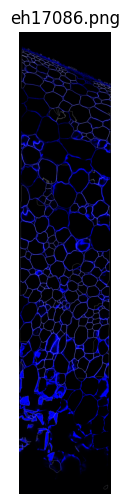

In [ ]:
from cellpose import io, models
from pathlib import Path
import matplotlib.pyplot as plt

# Path to your images
image_folder = "/content/drive/MyDrive/testdatapng"
image_files = sorted([f for f in Path(image_folder).glob("*.jpeg")])

# Load your trained model
model_path = "/content/models/new_model"
model = models.CellposeModel(gpu=True, pretrained_model=model_path)

# Loop over all images
for img_path in image_files:
    img = io.imread(str(img_path))

    # Run segmentation
    masks, flows, styles = model.eval([img], channels=[0,0], batch_size=1)

    # Plot the image and predicted masks
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap='gray')
    plt.axis("off")

    # Overlay predicted masks outlines
    from cellpose import utils
    outlines = utils.masks_to_outlines(masks[0])
    outX, outY = outlines.nonzero()
    img_out = img.copy()
    img_out[outX, outY] = 255  # highlight mask edges
    plt.imshow(img_out, cmap='gray')

    plt.title(img_path.name)
    plt.show()


In [ ]:
!pip install git+https://www.github.com/mouseland/cellpose.git
import matplotlib.pyplot as plt
from cellpose import plot, io, models, utils, transforms, core
from pathlib import Path
import numpy as np

# Re-define model path and load the model (as it might be in a separate execution context)
model_path = "/content/models/new_model"
model = models.CellposeModel(gpu=True, pretrained_model=model_path)

# Define the image folder
image_folder = "/content/drive/MyDrive/testdatapng"

# --- Diagnostic Step: List contents of the folder ---
print(f"Listing contents of {image_folder}:")
!ls -lh "{image_folder}"
print("------------------------------------------")
# --- End Diagnostic Step ---

image_files = sorted([f for f in Path(image_folder).glob("*.png")])

if not image_files:
    raise FileNotFoundError(f"No PNG images found in {image_folder}")

# Take the first image from the test set
img_path = image_files[0]
img = io.imread(str(img_path))

# Run segmentation to get masks and flows for this image
masks, flows, styles = model.eval([img], channels=[0,0], batch_size=1)

# Ensure masks and flows are extracted from the list returned by model.eval
masks = masks[0]
flows = flows[0]

fig = plt.figure(figsize=(12, 5))
plot.show_segmentation(
    fig,
    img,
    masks,
    flows[0],   # flow
    flows[1]    # cellprob or grad
)
plt.show()

  Cloning https://www.github.com/mouseland/cellpose.git to /tmp/pip-req-build-ka7efaf_
  Running command git clone --filter=blob:none --quiet https://www.github.com/mouseland/cellpose.git /tmp/pip-req-build-ka7efaf_
  Resolved https://www.github.com/mouseland/cellpose.git to commit 17fb25f40055ec2636aa708dc4cf6625b8b4735d
  Preparing metadata (setup.py) ... done


Listing contents of /content/drive/MyDrive/testdatapng:
ls: cannot access '/content/drive/MyDrive/testdatapng': No such file or directory
------------------------------------------


FileNotFoundError: No PNG images found in /content/drive/MyDrive/testdatapng

ROIS


In [ ]:
from skimage import measure

regions = measure.regionprops(masks)
roi_count = len(regions)
areas = [r.area for r in regions]
mean_area = np.mean(areas)
total_area = np.sum(areas)

print(f"Number of ROIs: {roi_count}")
print(f"Mean area: {mean_area:.2f}")
print(f"Total area: {total_area:.2f}")


Number of ROIs: 314
Mean area: 7297.94
Total area: 2291553.00
